## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting?
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

1. Regression is when we try to predict a numerical outcome, and classification is when we try to predict a categorical outcome.
2. We use confusion tables or confusion matrices to measure the performance of a particular classifier. To make a confusion table, we corss-tabulate predicted and true values and looks patterns in successes and failures. Confusion tables help us understand a model's performance by identifying true positives, true negatives, false positives, and false negatives by examining predicted versus true values.
3. The sum of squared error (SSE) quantifies the total and unexplained variation between a model's predicted values and the observed values.
4. Overfitting is when the model is unrealistically precise, or when k is very small. It's also when the model picks up training noise that isn't helpful to the model. Underfitting is when the model is unrealistically imprecise, or when k is very large. It's when a model is too simple to learn the underlying structure.
5. Splitting the data into training and testing sets improves model performance because it ensures that the model is applied to new data rather than simply memorizing old data. It prevents overfitting because it provides new and unseen data. Choosing k by evaluating accuracy or SSE on the test set improves model performance because it balances the effects of overfitting and underfitting. An extremely small k makes the model too complex, leading to overfitting. An extremely large k oversimplifies the model, leading to underfitting. Choosing an optimal k balances both effects, resulting in a stable model.
6. Class label predictions, also known as hard classificiation, makes a brute force decision based on a certain threshold (typically 50%). It provides a final answer needed for any immediate action and requires less storage and simpler logic. However, there's a loss of information about confidence. For example, it doesn't distinguish between a strong 99% prediction or a borderline 51% one. Probability distributions express confidence across all potential classes. It measures uncertainty and lays out important information about how confident the model is. It also allows adjustments in the decision threshold. However, it required calibration and is much more complex in terms of logic.

**Q2.** This question is a case study for $k$ nearest neighbor regression, using the `USA_cars_datasets.csv` data.

The target variable `y` is `price` and the features are `year` and `mileage`.

1. Load the `./data/USA_cars_datasets.csv`. Keep the following variables and drop the rest: `price`, `year`, `mileage`. Are there any `NA`'s to handle? Look at the head and dimensions of the data.
2. Maxmin normalize `year` and `mileage`.
3. Split the sample into ~80% for training and ~20% for evaluation.
4. Use the $k$NN algorithm and the training data to predict `price` using `year` and `mileage` for the test set for $k=3,10,25,50,100,300$. For each value of $k$, compute the mean squared error and print a scatterplot showing the test value plotted against the predicted value. What patterns do you notice as you increase $k$?
5. Determine the optimal $k$ for these data.
6. Describe what happened in the plots of predicted versus actual prices as $k$ varied, taking your answer into part 6 into account. (Hint: Use the words "underfitting" and "overfitting".)

   price  year  mileage
0   6300  2008   274117
1   2899  2011   190552
2   5350  2018    39590
3  25000  2014    64146
4  27700  2018     6654
(2499, 3)
   price      year   mileage
0   6300  0.744681  0.269287
1   2899  0.808511  0.187194
2   5350  0.957447  0.038892
3  25000  0.872340  0.063016
4  27700  0.957447  0.006537
k = 3: Mean Squared Error = 148065935.51955554


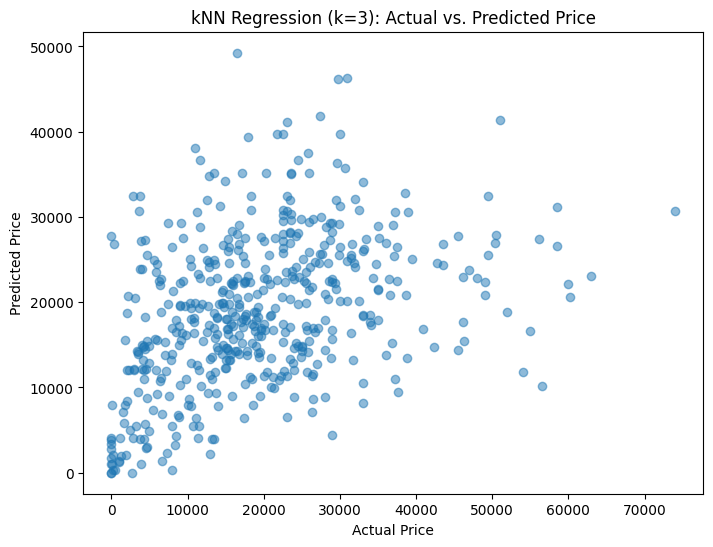

k = 10: Mean Squared Error = 117399126.10604002


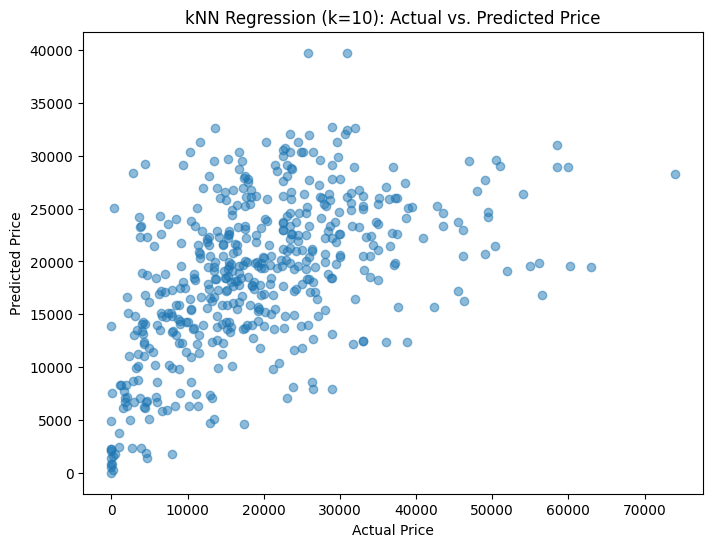

k = 25: Mean Squared Error = 112576160.82390079


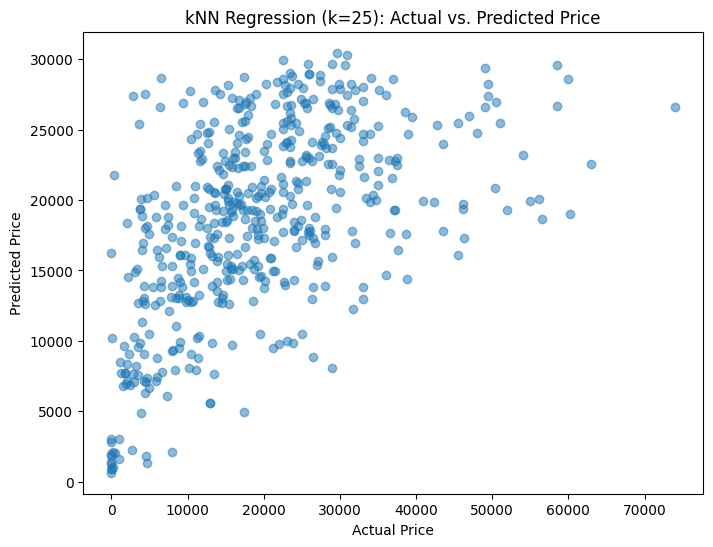

k = 50: Mean Squared Error = 110202549.3014296


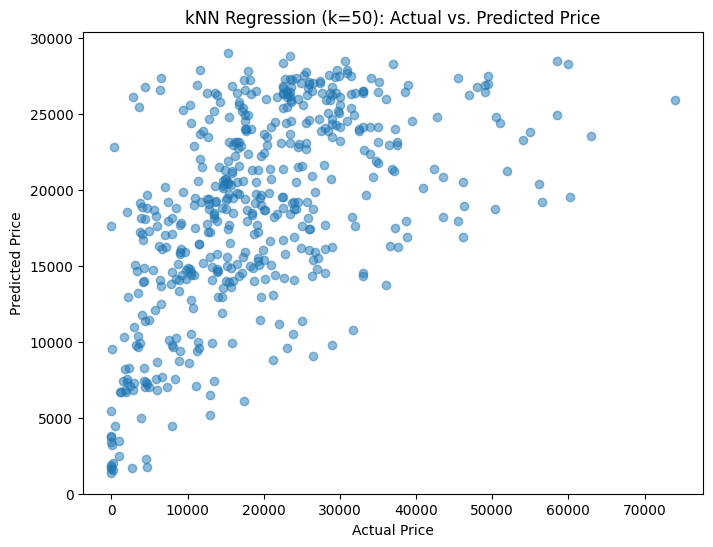

k = 100: Mean Squared Error = 112253932.8184272


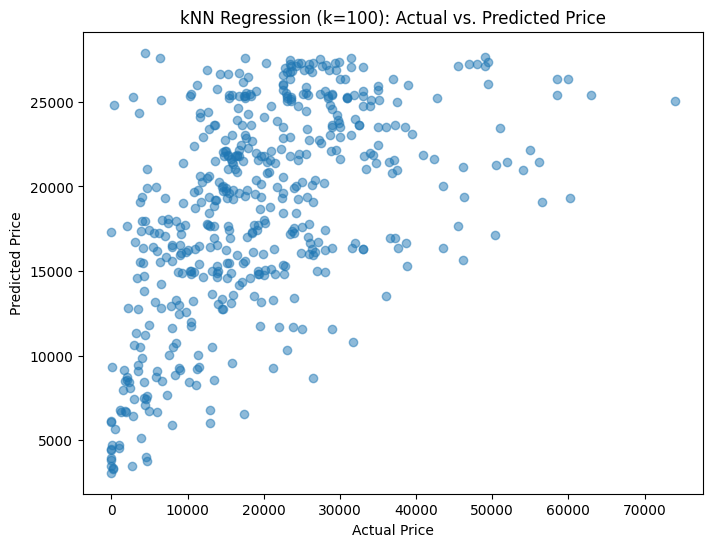

k = 300: Mean Squared Error = 114496301.82933456


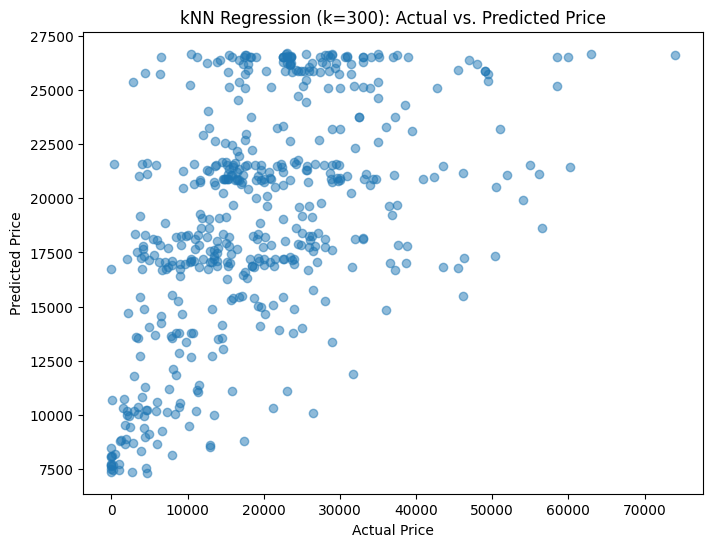


The optimal value of k is: 50 with an SSE of: 55101274650.7148


In [ ]:
#Question 2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

#2.1
cars = pd.read_csv('USA_cars_datasets.csv')
columns_to_keep = ['price','year','mileage']
cars = cars.drop(columns = [col for col in cars.columns if col not in columns_to_keep])
cars = cars.fillna(0)
cars['year'] = pd.to_numeric(cars['year'], errors='coerce')
cars['price'] = pd.to_numeric(cars['price'], errors='coerce')
cars['mileage'] = pd.to_numeric(cars['mileage'], errors='coerce')
print(cars.head())
print(cars.shape)

#2.2
#instead of creating a maxmin function and applying it to the whole dataframe, I did it individually since not every column should be normalized
cars['year'] = (cars['year'] - cars['year'].min()) / (cars['year'].max() - cars['year'].min())
cars['mileage'] = (cars['mileage'] - cars['mileage'].min()) / (cars['mileage'].max() - cars['mileage'].min())
print(cars.head())

#2.3
X = cars[['year', 'mileage']]
y = cars['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#2.4
SSE = {} #for 2.5
k_values = [3, 10, 25, 50, 100, 300]
for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k)
    fitted_model = model.fit(X_train, y_train)
    y_hat = fitted_model.predict(X_test)
    SSE[k] = np.sum((y_test-y_hat)**2)
    mse = mean_squared_error(y_test, y_hat)
    print(f"k = {k}: Mean Squared Error = {mse}")

    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, y_hat, alpha=0.5)
    plt.xlabel("Actual Price")
    plt.ylabel("Predicted Price")
    plt.title(f"kNN Regression (k={k}): Actual vs. Predicted Price")
    #plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.show()
#As I increase k, I notice that the graphs become more spread out horizontally. Initially,
# a lot of the data is clustered around the bottom left of the graph. As k increases, however,
# the values spread more horizontally, decreasing the size of the cluster.
# Furthermore, the values seem to spread diagonally as k increases as well.

#2.5
optimal_val = float('inf')
optimal_k = -1
for k, value in SSE.items():
    if value < optimal_val:
        optimal_val = value
        optimal_k = k
print("")
print(f"The optimal value of k is: {optimal_k} with an SSE of: {optimal_val}")
#optimal k is 50

#2.6
#For values below the optimal k, the mean squared error is extremely high.
# For example, the mean squared error for k=3 was higher than the mean squared
# error for k=10, and so on until k=50. The mean squared error is lowest for k=50
# and then picks up again for values of k greater than 50. For k values less than 50,
# the model was unrealistically precise, resulting in overfitting. For k values greater
# than 50, the model was unrealistically imprecise, resulting in underfitting.


**Q3.** This is a case study on $k$ nearest neighbor classification, using the `animals.csv` data.

The data consist of a label, `class`, taking integer values 1 to 7, the name of the species, `animal`, and 16 characteristics of the animal, including `hair`, `feathers`, `milk`, `eggs`, `airborne`, and so on.

1. Load the data. For each of the seven class labels, print the values in the class and get a sense of what is included in that group. Perform some other EDA: How big are the classes? How much variation is there in each of the features/covariates? Which variables do you think will best predict which class?
2. Split the data 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Using all of the variables, build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate it is? Can you interpret why mistakes are made across groups?
5. Use only `milk`, `aquatic`, and `airborne` to train a new $k$-NN classifier. Print your confusion table. Mine does not predict all of the classes, only a subset of them. To see the underlying probabilities, use `model.predict_proba(X_test.values)` to predict probabilities rather than labels for your `X_test` test data for your fitted `model`. Are all of the classes represented? Explain your results.

In [ ]:
#Question 3

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import accuracy_score


#3.1
zoo = pd.read_csv('zoo.csv')

print("Animals in each class:")
for label in sorted(zoo['class'].unique()):
    print(f"Class {label}:")
    display(zoo[zoo['class'] == label])
print("Class distribution:")
display(zoo['class'].value_counts().sort_index())
print("Variation in features (binary features):")
for column in zoo.columns[2:-1]:
    print(f"{column} feature distribution:")
    display(zoo[column].value_counts())

binary_features = [col for col in zoo.columns if col not in ['animal', 'class']]
class_feature_prevalence = zoo.groupby('class')[binary_features].mean()
print("Prevalence of binary features across different classes:")
display(class_feature_prevalence)

#The variables that are likely to be good predictors in this dataset are milk, feathers, eggs, backbone, fins, breathes, and legs.
# Milk has a value of 1.0 for class 1 and 0.0 for all other classes, implying that it's an extremely strong predictor for class 1.
# Feathers is a good indicator for class 2 because it has a vlaue of 1.0 for that class and 0.0 for all others. Eggs has a high
# prevalence across most classes but has an extreme low value of 0.024 for class 1, so it would be a good differentiator for
# class 1 (mammals). Backbone has 1.0 for classes 1-6 and a value of 0.0 for class 7, so it’s a good predictor for class 7.
# Fins is a good predictor for class 4, since it has a value of 1.0 for class 4 and mostly 0.0 for others. Breathes has a 0.0
# for class 4 as well, so it’s a good indicator for that class. Legs isn’t strictly binary, but it shows distinct counts for
# class 4 (0.0) and class 6 (6.0).


print("DataFrame Info:")
zoo.info()
print("Descriptive statistics for numerical columns:")
display(zoo.describe())

#3.2
X = zoo.drop(['animal', 'class'], axis=1)
y = zoo['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

print(f"Training set size: {len(X_train)} samples")
print(f"Test set size: {len(X_test)} samples")

#3.3
accuracies = {}
max_k = len(X_train)
k_values = [i for i in range(1, max_k + 1)]

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    fitted_model = model.fit(X_train, y_train)
    y_hat = fitted_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_hat)
    accuracies[k] = accuracy

# Find the k with the highest accuracy
optimal_accuracy = -1
optimal_k = -1
for k, acc_val in accuracies.items():
    if acc_val > optimal_accuracy:
        optimal_accuracy = acc_val
        optimal_k = k

print(f"The optimal value of k is: {optimal_k} with an accuracy of: {optimal_accuracy}")

#3.4
#making regression using optimal model

optimal_model = KNeighborsClassifier(n_neighbors=optimal_k)
optimal_model.fit(X_train, y_train)
y_pred = optimal_model.predict(X_test)

print("Confusion table for the optimal model:")
confusion_mat = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])
display(confusion_mat)

correct_predictions = np.sum(np.diag(confusion_mat))
total_predictions = np.sum(confusion_mat.values)
accuracy_optimal = correct_predictions/total_predictions

print(f"Accuracy of the optimal model: {accuracy_optimal:.4f}")
#accuracy is 0.9412
# There were two instances in class 3 and one instance in class 7 where mistakes were
# made. This could be because the variables used to predict that class were weaker than
# the predictors for other classes or had similar correlations. For example, class 3 (amphibians)
# is misclassified as class 4 (fish) and class 5 (insects). Both amphibians and fish lay eggs
# and both can be aquatic. Similarly, both amphibians and insects lay eggs and both have eggs.
# Since they share similar traits and thus have similar values for certain indicators, it's totally possible
# the model made a mistake in classifying the correct class. Similarly, class 7 was identified as
# class 6.

#3.5
print("\nRevised Model Based on Milk, Aquatic, Airborne: ")
X_revised = zoo[['milk', 'aquatic', 'airborne']]
y_revised = zoo['class']
X_train_revised, X_test_revised, y_train_revised, y_test_revised = train_test_split(X_revised, y_revised, test_size=0.5, random_state=42)

print(f"Revised training set size: {len(X_train_revised)} samples")
print(f"Revised test set size: {len(X_test_revised)} samples")

accuracies_revised = {}
max_k_revised = len(X_train_revised)
k_values_revised = [i for i in range(1, max_k_revised + 1)]

for k_revised in k_values_revised:
    model_revised = KNeighborsClassifier(n_neighbors=k_revised)
    fitted_model_revised = model_revised.fit(X_train_revised, y_train_revised)
    y_hat_revised = fitted_model_revised.predict(X_test_revised)
    accuracy_revised = accuracy_score(y_test_revised, y_hat_revised)
    accuracies_revised[k_revised] = accuracy_revised

optimal_accuracy_revised = -1
optimal_k_revised = -1
for k_revised, acc_val_revised in accuracies_revised.items():
    if acc_val > optimal_accuracy_revised:
        optimal_accuracy_revised = acc_val
        optimal_k_revised = k_revised

print(f"The optimal value of k for the revised classifier is: {optimal_k_revised} with an accuracy of: {optimal_accuracy_revised}")

# Build the optimal classifier model for Q3.5
optimal_classifier_revised = KNeighborsClassifier(n_neighbors=optimal_k_revised)
optimal_classifier_revised.fit(X_train_revised, y_train_revised)
y_pred_revised = optimal_classifier_revised.predict(X_test_revised)

print("Confusion table for the optimal revised classifier:")
confusion_mat_revised = pd.crosstab(y_test_revised, y_pred_revised, rownames=['Actual'], colnames=['Predicted'])
display(confusion_mat_revised)

accuracy_revised = accuracy_score(y_test_revised, y_pred_revised)
print(f"Accuracy of the optimal revised classifier: {accuracy_revised}")


probabilities = optimal_classifier_revised.predict_proba(X_test_revised)
print(f"Probabilities of class labels: {probabilities}")

actual_unique_classes = sorted(y_test_revised.unique())
predicted_unique_classes_from_labels = sorted(np.unique(y_pred_revised))

print(f"Actual unique classes in test set: {actual_unique_classes}")
print(f"Unique classes predicted by the model: {predicted_unique_classes_from_labels}")

#The actual classes represented in this new confusion matrix are classes 1, 2, 4, and 7.
# This is because we're limiting our predictors to milk, aquatic, and airborne, leading to
# some classes being indistinguishable. As a result, there's a lower accuracy and the exclusion
# of some classes, which we see above.



Animals in each class:
Class 1:


,animal,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1
5,buffalo,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
6,calf,1,0,0,1,0,0,0,1,1,1,0,0,4,1,1,1,1
9,cavy,1,0,0,1,0,0,0,1,1,1,0,0,4,0,1,0,1
10,cheetah,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1
17,deer,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
19,dolphin,0,0,0,1,0,1,1,1,1,1,0,1,0,1,0,1,1


Class 2:


,animal,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class
11,chicken,0,1,1,0,1,0,0,0,1,1,0,0,2,1,1,0,2
16,crow,0,1,1,0,1,0,1,0,1,1,0,0,2,1,0,0,2
20,dove,0,1,1,0,1,0,0,0,1,1,0,0,2,1,1,0,2
21,duck,0,1,1,0,1,1,0,0,1,1,0,0,2,1,0,0,2
23,flamingo,0,1,1,0,1,0,0,0,1,1,0,0,2,1,0,1,2
33,gull,0,1,1,0,1,1,1,0,1,1,0,0,2,1,0,0,2
37,hawk,0,1,1,0,1,0,1,0,1,1,0,0,2,1,0,0,2
41,kiwi,0,1,1,0,0,0,1,0,1,1,0,0,2,1,0,0,2
43,lark,0,1,1,0,1,0,0,0,1,1,0,0,2,1,0,0,2
56,ostrich,0,1,1,0,0,0,0,0,1,1,0,0,2,1,0,1,2


Class 3:


...

Training set size: 50 samples
Test set size: 51 samples
The optimal value of k is: 1 with an accuracy of: 0.9411764705882353
Confusion table for the optimal model:


Predicted,1,2,3,4,5,6,7
Actual,,,,,,,
1,24,0,0,0,0,0,0
2,0,6,0,0,0,0,0
3,0,0,1,1,1,0,0
4,0,0,0,5,0,0,0
5,0,0,0,0,3,0,0
6,0,0,0,0,0,5,0
7,0,0,0,0,0,1,4


Accuracy of the optimal model: 0.9412

Revised Model Based on Milk, Aquatic, Airborne: 
Revised training set size: 50 samples
Revised test set size: 51 samples
The optimal value of k for the revised classifier is: 1 with an accuracy of: 0.47058823529411764
Confusion table for the optimal revised classifier:


Predicted,1,2,4,7
Actual,,,,
1,24,0,0,0
2,0,6,0,0
3,0,0,1,2
4,0,0,5,0
5,0,0,3,0
6,0,5,0,0
7,0,0,3,2


Accuracy of the optimal revised classifier: 0.7254901960784313
Probabilities of class labels: [[1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0

**Q4.** Write your own function to make a kernel density plot.

- The user should pass in a Pandas series or Numpy array.
- The default kernel should be Gaussian, but include the uniform/bump and Epanechnikov as alternatives.
- The default bandwidth should be the Silverman plug-in, but allow the user to specify an alternative.
- You can use Matplotlib or Seaborn's `.lineplot`, but not an existing function that creates kernel density plots.

You will have to make a lot of choices and experiment with getting errors. Embrace the challenge and track your choices in the comments in your code.

Use a data set from class to show that your function works, and compare it with the Seaborn `kdeplot`.

We covered the Gaussian,
$$
k(z) = \dfrac{1}{\sqrt{2\pi}}e^{-z^2/2}
$$
and uniform
$$
k(z) = \begin{cases}
\frac{1}{2}, & |z| \le 1 \\
0, & |z|>1
\end{cases}
$$
kernels in class, but the Epanechnikov kernel is
$$
k(z) = \begin{cases}
\frac{3}{4} (1-z^2), & |z| \le 1 \\
0, & |z|>1.
\end{cases}
$$

In order to make your code run reasonably quickly, consider using the `pdist` or `cdist` functions from SciPy to make distance calculations for arrays of points. The other leading alternative is to thoughtfully use NumPy's broadcasting features. Writing `for` loops will be slow, but that's fine.

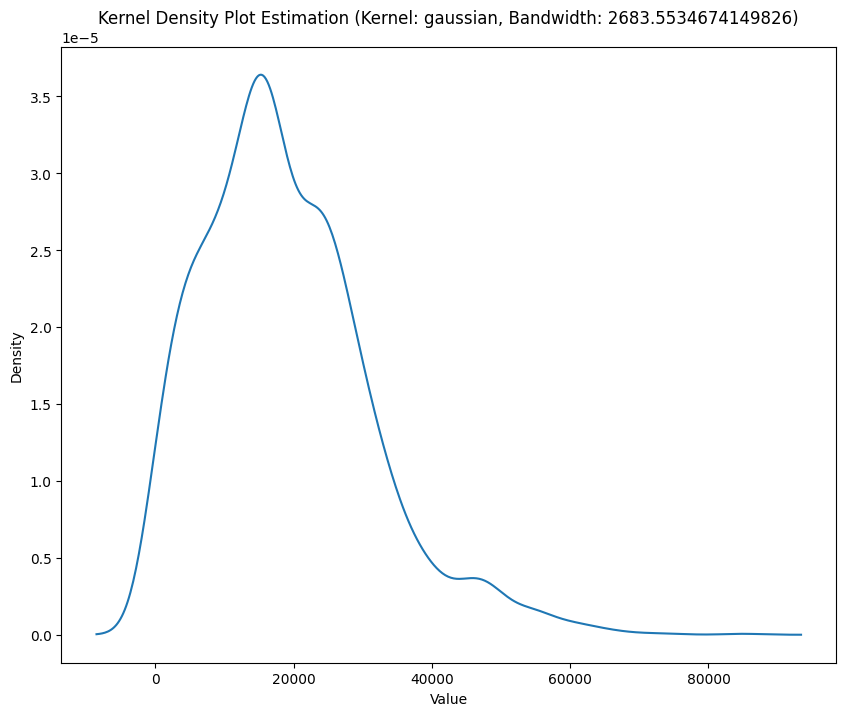

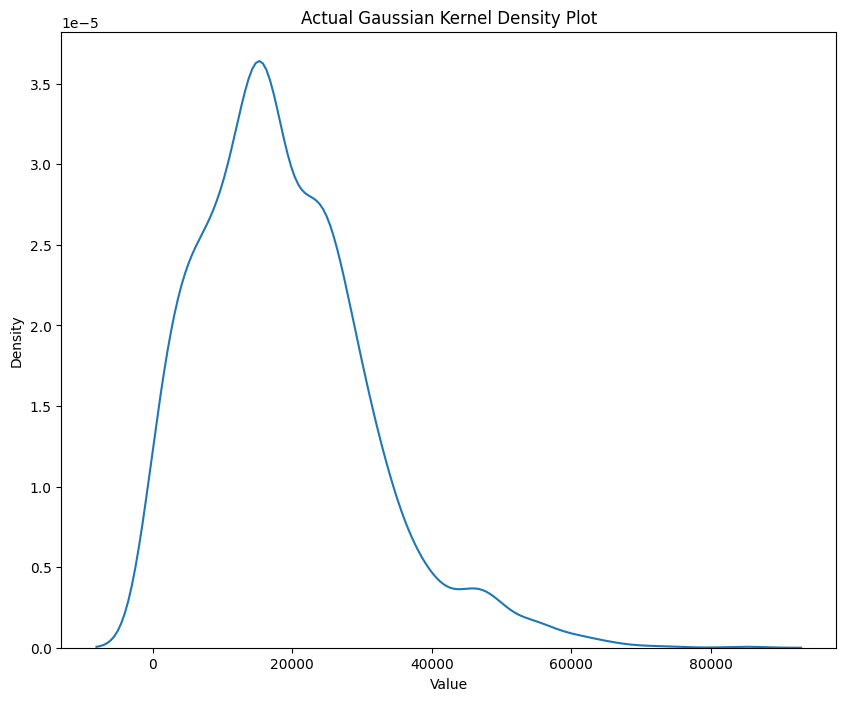

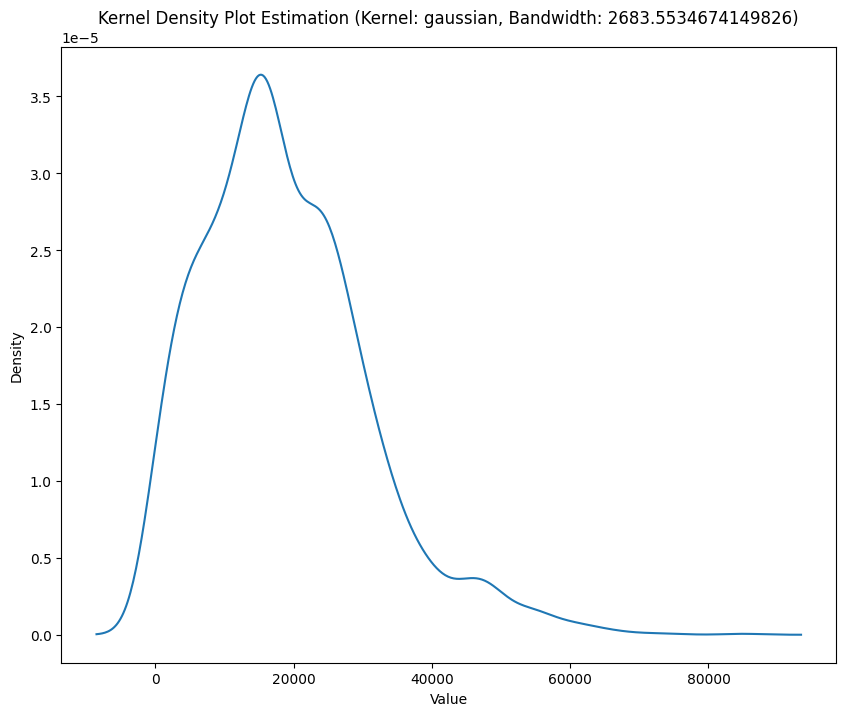

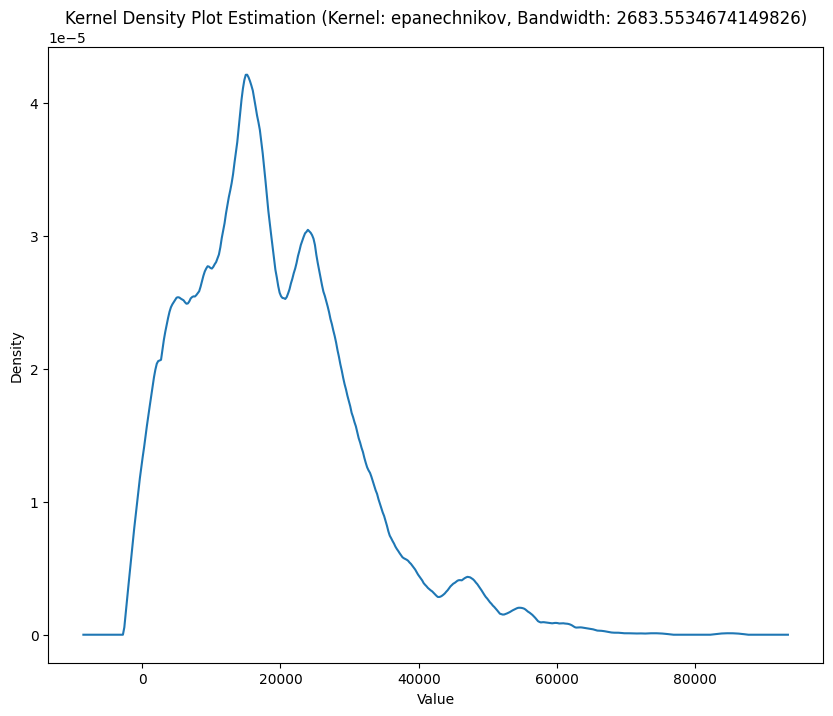

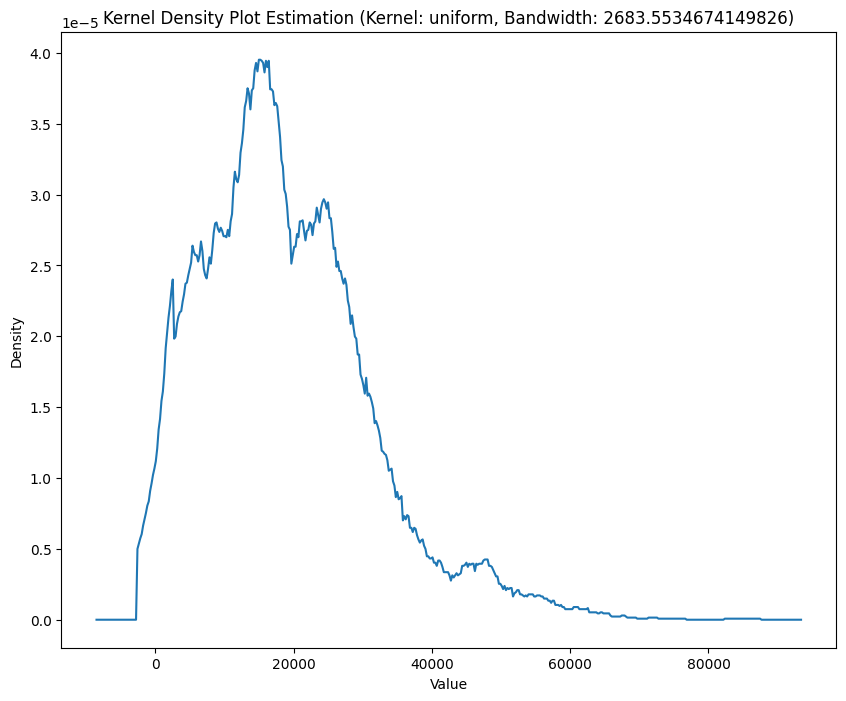

''

In [14]:
#Question 4
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import scipy.stats as stats
from scipy.spatial.distance import pdist, cdist
from scipy.stats import gaussian_kde

#default guassian kernel calculation
def guassianKernel(z):
  constant = 1/np.sqrt(2*np.pi)
  return constant * np.exp(-0.5 * (z**2)) # Corrected: exponent should be negative

#alternative uniform kernel calculation
def uniform(z):
  return 0.5 * (np.abs(z) <= 1)

#alternative epanechnikov calculation
def epanechnikov(z):
  return 0.75 * (1 - z**2) * (np.abs(z) <= 1)

#calculating default bandwidth using Silverman plug-in
def calculateBandwidth(data):
  #data = np.asarray(data)
  n = len(data)
  std = np.std(data)
  return (((4*(std**5))/(3*n))**0.2)


def kde_estimation(data, kernel_func, bandwidth):
  #converts data to an array in case it was given as a series
  data = np.asarray(data)
  n = len(data)
  num_points = 500
  #assigning bandwidth
  if(bandwidth == None):
    bandwidth = calculateBandwidth(data)

  data_min, data_max = np.min(data), np.max(data)
  x_range = data_max-data_min
  margin = x_range*0.1
  x_values = np.linspace(data_min-margin, data_max+margin, num_points)

  y_values = np.zeros(num_points)

  #chose to do for loops just because it made most sense to me
  for i, x in enumerate(x_values):
      z = (x - data)/bandwidth
      kernel_outputs = kernel_func(z)
      y_values[i] = np.sum(kernel_outputs)/(n * bandwidth)

  return x_values, y_values

def kernelDensityPlot(data, kernel_choice, bandwidth, num_points=500):
  #checking to see what the kernel choice is to see which function to run
  if(kernel_choice.lower() == "guassian"):
    kernel_func = guassianKernel
  elif(kernel_choice.lower() == "uniform"):
    kernel_func = uniform
  elif(kernel_choice.lower() == "epanechnikov"):
    kernel_func = epanechnikov
  else:
    kernel_func = guassianKernel

  #checking to see if user provided a bandwidth, else plug in Silverman's
  if bandwidth is None:
    bandwidth = calculateBandwidth(data)

  #perform KDE estimation on values
  x_kde, y_kde = kde_estimation(data, kernel_func, bandwidth)
  plt.figure(figsize=(10,8))
  sns.lineplot(x=x_kde,y=y_kde)
  plt.title(f"Kernel Density Plot Estimation (Kernel: {kernel_choice}, Bandwidth: {bandwidth})")
  plt.xlabel("Value")
  plt.ylabel("Density")
  plt.show()
  return "";


cars = pd.read_csv('USA_cars_datasets.csv')
columns_to_keep = ['price','year','mileage']
cars = cars.drop(columns = [col for col in cars.columns if col not in columns_to_keep])
cars = cars.fillna(0)
cars['year'] = pd.to_numeric(cars['year'], errors='coerce')
cars['price'] = pd.to_numeric(cars['price'], errors='coerce')
cars['mileage'] = pd.to_numeric(cars['mileage'], errors='coerce')

sample_data = cars['price']
#going to go with default bandwidth for testing purposes
default_bandwidth = calculateBandwidth(sample_data)

# testing gaussian kernel
test = kernelDensityPlot(sample_data, kernel_choice='gaussian', bandwidth=default_bandwidth)
plt.figure(figsize=(10,8))
sns.kdeplot(x=sample_data, label=f'Seaborn KDE (Gaussian, h={default_bandwidth:.2f})', bw_method='silverman')
plt.title('Actual Gaussian Kernel Density Plot')
plt.xlabel('Value')
plt.ylabel('Density')
plt.show()
#both graphs appear to be identical, proving that my method works!

#seaborn visually appear identical across kernel choices, so i can't check my estimations for epanechnikov and uniform kernels.
#instead, i'll plot all three kernel estimations to see if and how they appear visually distinct form one another
# the below code was used to test it

#sns.kdeplot(x=sample_data, kernel='gaussian', bw_method='silverman', label='Gaussian')
#sns.kdeplot(x=sample_data, kernel='epa', bw_method='silverman', linestyle='--', label='Epanechnikov')
#plt.legend()
#plt.title('Seaborn KDE Kernel Check')
#plt.show()

#showing all three graphs
kernelDensityPlot(sample_data, 'gaussian', default_bandwidth)
kernelDensityPlot(sample_data, 'epanechnikov', default_bandwidth)
kernelDensityPlot(sample_data, 'uniform', default_bandwidth)

